Importation des bibliothèques :


In [1]:
from scipy.stats import skew, kurtosis
import yfinance as yf
import numpy as np
import pandas as pd
import pysdtest
import matplotlib.pyplot as plt

question 1 : récupération des actions du cac40 et du cac40

In [2]:
cac40_tickers=["AC.PA", "AI.PA", "AIR.PA", "MT.AS", "CS.PA", "BNP.PA", "EN.PA","CAP.PA", "CA.PA", "ACA.PA", "BN.PA","DSY.PA", "EDEN.PA", "ENGI.PA", "EL.PA",
"ERF.PA", "RMS.PA", "KER.PA", "LR.PA", "OR.PA", "MC.PA", "ML.PA", "ORA.PA",
"RI.PA", "PUB.PA", "RNO.PA", "SAF.PA", "SGO.PA", "SAN.PA", "SU.PA", "GLE.PA",
 "STLAP.PA", "STMPA.PA", "TEP.PA", "HO.PA", "TTE.PA", "URW.PA", "VIE.PA", "DG.PA",
"VIV.PA"]

indice_cac40=["^FCHI"]
#téléchargement du cour des actions du cac40 
data_action=yf.download(cac40_tickers, start="2014-01-01", end="2024-12-31",auto_adjust=True)["Close"]
#téléchargement du cour du cac40 
data_cac40=yf.download(indice_cac40, start="2014-01-01", end="2024-12-31",auto_adjust=True)["Close"]



# Colonnes contenant au moins un NaN
cols_with_nan = data_action.columns[data_action.isna().any()]

# Nombre d'actions supprimées
nb_supprimees = len(cols_with_nan)
# Suppression des actions ayant des NaN
data_action = data_action.drop(columns=cols_with_nan)
#Faire en sorte d'avoir exactement les même dates pour les 2 dataframes
data_action, data_cac40 = data_action.align(data_cac40, join='inner', axis=0)
# On garde comme tickker seulement ceux des actions sans NaN
cac40_tickers=[x for x in cac40_tickers if x  in data_action.columns]
print(data_action)
print(data_cac40)

[*********************100%***********************]  40 of 40 completed
[*********************100%***********************]  1 of 1 completed

Ticker          AC.PA     ACA.PA       AI.PA      AIR.PA      BN.PA  \
Date                                                                  
2014-01-02  27.877777   4.584194   47.221336   47.453815  35.817299   
2014-01-03  28.029173   4.546505   47.501999   47.327950  35.970421   
2014-01-06  27.918695   4.611966   46.543076   46.513969  35.622410   
2014-01-07  28.233765   4.892155   45.818027   46.916759  36.067867   
2014-01-08  28.340155   4.947697   46.201599   46.446835  35.615448   
...               ...        ...         ...         ...        ...   
2024-12-20  45.344044  12.179414  152.632706  151.377243  62.289360   
2024-12-23  45.188354  12.193456  151.512863  150.516586  62.425446   
2024-12-24  45.246738  12.085798  151.611099  150.320984  62.269913   
2024-12-27  45.490002  12.380689  153.143509  151.885818  62.969795   
2024-12-30  45.441349  12.455581  151.886139  150.986038  62.697620   

Ticker         BNP.PA      CA.PA      CAP.PA      CS.PA      DG.PA  ...  \
D

question 2: On génère 100 portefeuilles composés d'au moins 2 actions 

In [3]:
portefeuilles={}
for i in range(1,101):
    nb_action = np.random.randint(2, 39) #prend un nombre d'action aléatoire entre 2 et 38
    #prend le nombre d'action choisi aléatoirement dans cac40_tickers
    actions_du_portefeuille=np.random.choice(cac40_tickers, size=nb_action,replace=False)
    poids = np.random.rand(nb_action)
    # on s'assure que la somme des poids fassent 1
    poids = poids / np.sum(poids)
    #on cree un dictionnaire liant chaque action à son poids dans le portrfeuille 
    portefeuilles[f"P{i}"] = {"actions": actions_du_portefeuille,"poids": poids}
print(portefeuilles)

{'P1': {'actions': array(['KER.PA', 'RMS.PA', 'BNP.PA', 'DSY.PA', 'SU.PA', 'EN.PA', 'SAF.PA',
       'MC.PA', 'TTE.PA', 'AC.PA', 'STLAP.PA', 'BN.PA', 'VIE.PA',
       'STMPA.PA', 'CS.PA', 'ML.PA', 'GLE.PA', 'VIV.PA', 'OR.PA',
       'CAP.PA', 'ERF.PA', 'SAN.PA', 'RI.PA', 'HO.PA', 'ACA.PA', 'PUB.PA',
       'AIR.PA', 'RNO.PA', 'EDEN.PA', 'LR.PA', 'ORA.PA', 'EL.PA',
       'ENGI.PA', 'AI.PA', 'SGO.PA', 'TEP.PA'], dtype='<U8'), 'poids': array([0.02107843, 0.04781477, 0.01978062, 0.031736  , 0.02611388,
       0.01696976, 0.00053479, 0.01807995, 0.04896066, 0.0541753 ,
       0.00044228, 0.02844683, 0.02839877, 0.05520805, 0.05038521,
       0.04556013, 0.0416719 , 0.05513113, 0.03664222, 0.01467809,
       0.01923956, 0.02607098, 0.01328848, 0.02731813, 0.02470148,
       0.00471302, 0.00707047, 0.03453336, 0.02489733, 0.00393191,
       0.04886706, 0.05821224, 0.00986047, 0.02890911, 0.00786798,
       0.01870963])}, 'P2': {'actions': array(['BN.PA', 'OR.PA', 'SAN.PA', 'CAP.PA', 'AI.PA',

question 3: Génération des matrices de rendements journaliers des portefeuilles et du cac40

In [4]:
# création de la matrice des rendements journaliers des actions
rendements_actions = data_action.pct_change()

# liste pour stocker les DataFrames temporaires
liste_dataframe_temporaire = []

# boucle sur les 100 portefeuilles
for k in range(1, 101):
    # actions et poids du portefeuille k
    actions = portefeuilles[f"P{k}"]["actions"]
    poids = np.array(portefeuilles[f"P{k}"]["poids"])

    # on extrait les prix des actions du portefeuille et supprimer les jours avec NaN
    prix_portefeuille = data_action[actions].dropna(axis=0)

    # on calcule les rendements journaliers de ces actions
    rendements_actions_portefeuille = prix_portefeuille.pct_change().dropna()

    # on calcule le rendement journalier du portefeuille 
    r_portefeuille = (rendements_actions_portefeuille * poids).sum(axis=1)

    # DataFrame temporaire pour le portefeuille Pk
    dataframe_temporaire = pd.DataFrame({f"P{k}": r_portefeuille})

    liste_dataframe_temporaire.append(dataframe_temporaire)

# rendements journaliers du CAC 40
rdt_cac = data_cac40.pct_change().dropna()
rdt_cac.columns = ["CAC40"]

liste_dataframe_temporaire.append(rdt_cac)

# concaténation de la liste pour obtenir la matrice finale des rendements
rendements_portefeuilles = pd.concat(liste_dataframe_temporaire, axis=1)
print(rendements_portefeuilles)

                  P1        P2        P3        P4        P5        P6  \
Date                                                                     
2014-01-03  0.003994  0.002742  0.006823  0.000827  0.001241  0.003588   
2014-01-06 -0.005029 -0.006375 -0.001901 -0.004690 -0.006163 -0.005049   
2014-01-07  0.008600  0.008865  0.007008  0.007583  0.006878  0.003738   
2014-01-08  0.003104  0.001412  0.000514  0.004958  0.001569  0.002626   
2014-01-09 -0.006490 -0.003046 -0.006793 -0.003878 -0.006031 -0.007275   
...              ...       ...       ...       ...       ...       ...   
2024-12-20  0.000579 -0.003495 -0.000032 -0.001913 -0.002132 -0.002069   
2024-12-23 -0.000174  0.000256 -0.002564  0.000714 -0.001377 -0.000130   
2024-12-24  0.003112  0.002198  0.003629  0.002577  0.002070  0.003372   
2024-12-27  0.008603  0.008422  0.009092  0.009011  0.008454  0.007748   
2024-12-30 -0.005449 -0.005683 -0.004735 -0.006150 -0.005162 -0.004916   

                  P7        P8       

question 4: génération du vecteur des rendements annuels moyenS et du vecteur de variance journalière des portefeuilles

In [5]:
# Rendement sur l'année 2023
rendements_2023 = rendements_portefeuilles.loc["2023-01-01":"2023-12-31"]

# Vecteur des rendements annuels moyens
rendement_annuel_moyen = 252 * rendements_2023.mean()

# Vecteur des variances journalières
variance_journaliere = rendements_2023.var()

print(rendement_annuel_moyen)
print(variance_journaliere)

P1       0.211031
P2       0.266077
P3       0.171676
P4       0.242917
P5       0.258627
           ...   
P97      0.090543
P98      0.196080
P99      0.218851
P100     0.206715
CAC40    0.160729
Length: 101, dtype: float64
P1       0.000069
P2       0.000064
P3       0.000067
P4       0.000076
P5       0.000076
           ...   
P97      0.000077
P98      0.000065
P99      0.000084
P100     0.000063
CAC40    0.000076
Length: 101, dtype: float64


Question 5: Graphique du rendement annuel moyen en fonction de l'écart type des rendements journaliers avec le cac40 en rouge

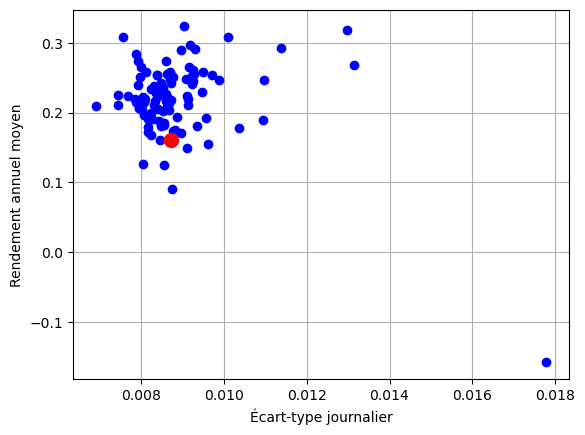

In [6]:
#vecteur des écart types journaliers
ecart_type_journalier = rendements_2023.std()


plt.plot(ecart_type_journalier, rendement_annuel_moyen, 'o', color='blue')
plt.plot(ecart_type_journalier['CAC40'], rendement_annuel_moyen['CAC40'], 'o', color='red', markersize=10)

plt.xlabel("Écart-type journalier")
plt.ylabel("Rendement annuel moyen")

plt.grid()

plt.show()

question 6: génération d'une matrice pour chaque ordre de dominance stochastique 

H0:portefeuille p domine stochastiquement à l'ordre s le cac40
Ha: le cac40 domine stochastiquement à l'ordre s le portefeuille p
Ma règle de décision est la suivante : niveau de confiance 95% on test si p-value>1-niveau de confiance c'est à dire si p-value>0.05 dans ce cas on ne rejette pas H0

Afin de réaliser le test j'ai décider d'utiliser la méthode de LMW avec comme sous échantillon 50 comme cela est indiqué dans l'exemple du bitcoin car cette méthode permet de prendre en compte la dépendance des données.


In [8]:
ngrid = 200
b = 50  # taille des sous-échantillons pour subsampling
année = range(2014, 2025)  # 2014 à 2024
#création d'une instance contenant seulement les nom des portefeuilles
portfolios = [c for c in rendements_portefeuilles.columns if c != "CAC40"]

# Création des matrices vides pour SD1 et SD2
SD1_matrix = pd.DataFrame(index=portfolios, columns=année)
SD2_matrix = pd.DataFrame(index=portfolios, columns=année)

# Boucle sur les portefeuilles et les années
for p in portfolios:
    print(f"Traitement du portefeuille {p}...")
    for y in année:
        # Sélection des rendements de l'année y
        echantillon_port = rendements_portefeuilles[p].loc[f"{y}-01-01":f"{y}-12-31"].to_numpy()
        echantillon_cac = rendements_portefeuilles["CAC40"].loc[f"{y}-01-01":f"{y}-12-31"].to_numpy()

        for s in [1, 2]:  # SD1 et SD2
            # Test portefeuille ⪰ CAC
            test = pysdtest.test_sd(
                echantillon_port,
                echantillon_cac,
                ngrid=ngrid,
                s=s,
                resampling="subsampling",
                b1=b,
                b2=b,
                quiet=True
            )
            test.testing()
            res = test.result


            # On regarde si on rejette H0 ou non
            if res['p_val'] > 0.05 :
                dominance_portefeuille=True  # hypothèse H0 non rejetée
            else:
                dominance_portefeuille=False #pas de dominance



                # Test inverse CAC ⪰ portefeuille
            test_inv = pysdtest.test_sd(
                echantillon_cac,
                echantillon_port,
                ngrid=ngrid,
                s=s,
                resampling="subsampling",
                b1=b,
                b2=b,
                quiet=True
                )
            test_inv.testing()
            res_inv = test_inv.result

         # On regarde si on rejette Ha ou non
            if res_inv['p_val'] > 0.05 :
                dominance_cac40=True  # hypothèse Ha non rejetée
            else:
                dominance_cac40=False # pas de dominance


#Test pour voir si il y a une dominance stochastique
#Si aucune des hypotheses n'est rejetées alors il n'y a pas de dominance stochastique
            if dominance_portefeuille==True and dominance_cac40==True:
                val=0
#Si les 2 hypotheses sont rejetées alors on il n'y a pas de dominance stochastique
            elif dominance_portefeuille==False and dominance_cac40==False:
                val=0
# Si l'hypothèse de dominance n'est pas rejeté seulement pour le portefeuille alors on mettra 1 dans la matrice
            elif dominance_portefeuille==True and dominance_cac40==False:
                val=1
# Si l'hypothèse de dominance n'est pas rejeté seulement pour le cac40 alors on mettra 2 dans la matrice
            else:
                val=2


            # Remplissage de la matrice
            if s == 1:
                SD1_matrix.loc[p, y] = val
            else:
                SD2_matrix.loc[p, y] = val

print(SD1_matrix)
print(SD2_matrix)

Traitement du portefeuille P1...
Traitement du portefeuille P2...
Traitement du portefeuille P3...
Traitement du portefeuille P4...
Traitement du portefeuille P5...
Traitement du portefeuille P6...
Traitement du portefeuille P7...
Traitement du portefeuille P8...
Traitement du portefeuille P9...
Traitement du portefeuille P10...
Traitement du portefeuille P11...
Traitement du portefeuille P12...
Traitement du portefeuille P13...
Traitement du portefeuille P14...
Traitement du portefeuille P15...
Traitement du portefeuille P16...
Traitement du portefeuille P17...
Traitement du portefeuille P18...
Traitement du portefeuille P19...
Traitement du portefeuille P20...
Traitement du portefeuille P21...
Traitement du portefeuille P22...
Traitement du portefeuille P23...
Traitement du portefeuille P24...
Traitement du portefeuille P25...
Traitement du portefeuille P26...
Traitement du portefeuille P27...
Traitement du portefeuille P28...
Traitement du portefeuille P29...
Traitement du portefeui

J ai essayé de reproduire ce qui était fait dans l exemple  du bitcoin et de résoudre certains problemes liés 
au resultat mais celui-ci me parait encore incorrect notamment dû au nombre de dominance stochastique à 
l ordre 1 et egalement dû au fait que la dominance stochastique à l ordre 1 n'implique pas la dominance
stochastique à l ordre 2.



question 7.1: graphique de la question 5 avec en vert les points correspondant aux portefeuilles dominants stochastiquement à l'ordre 1 le cac40

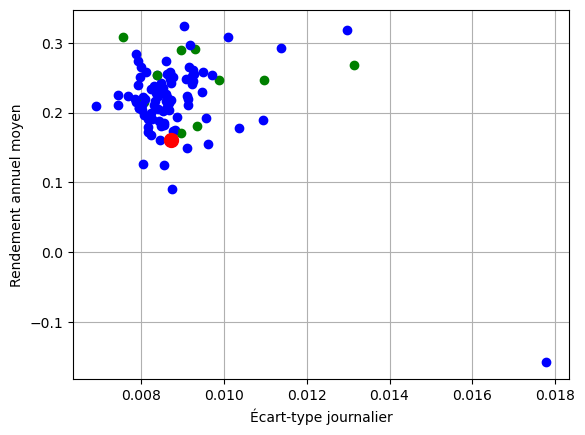

In [9]:
ecart_type_journalier = rendements_2023.std()

for p in ecart_type_journalier.index:

    if p == "CAC40":
        continue

    # Si le portefeuille domine le CAC40 on met un point vert
    if SD1_matrix.loc[p, 2023] == 1:
        plt.plot(ecart_type_journalier[p], rendement_annuel_moyen[p], 'o', color='green')
    else:
        plt.plot(ecart_type_journalier[p], rendement_annuel_moyen[p], 'o', color='blue')







plt.plot(ecart_type_journalier['CAC40'], rendement_annuel_moyen['CAC40'], 'o', color='red', markersize=10)

plt.xlabel("Écart-type journalier")
plt.ylabel("Rendement annuel moyen")

plt.grid()

plt.show()

Les portefeuille dominants stochastiquement à l'ordre 1 le cac 40 se situe au dessus de lui mais peuvent avoir un écart type journalier plus faible ou plus grand. Cela me parait cohérent pour le rendement annuel moyen mais le fait que certain est une volatilité plus grande me surprend un peu car pour qu'il y ait dominance stochastique à l'ordre 1 il faut que pour tout w P(W1>w)>=P(W2>w) or une grande fluctuation pourrait entrainer de forte descente et venir contredire cette dominance.

question 7.2:graphique question 5 avec en vert les points correspondant aux portefeuilles dominants stochastiquement à l'ordre 2 

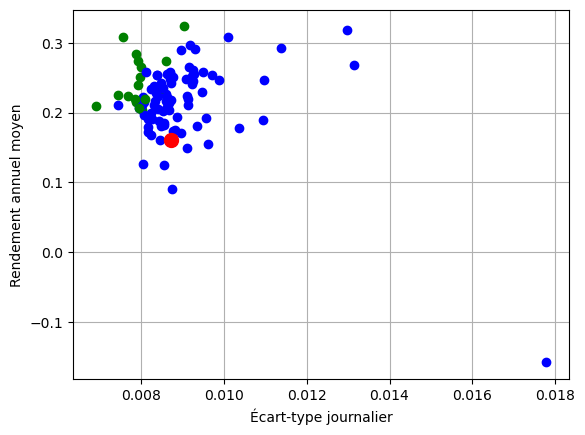

In [10]:
ecart_type_journalier = rendements_2023.std()

for p in ecart_type_journalier.index:

    if p == "CAC40":
        continue

    # Si le portefeuille domine le CAC40 on met un point vert
    if SD2_matrix.loc[p, 2023] == 1:
        plt.plot(ecart_type_journalier[p], rendement_annuel_moyen[p], 'o', color='green')
    else:
        plt.plot(ecart_type_journalier[p], rendement_annuel_moyen[p], 'o', color='blue')







plt.plot(ecart_type_journalier['CAC40'], rendement_annuel_moyen['CAC40'], 'o', color='red', markersize=10)

plt.xlabel("Écart-type journalier")
plt.ylabel("Rendement annuel moyen")

plt.grid()

plt.show()

On peut remarquer que les points dont les portefeuilles dominent stochastiquement le cac 40 se situe au dessus à gauche de lui sauf un
c est à dire avec un écart type journalier plus faible et un rendement annuel moyen plus élevé. 
Ce qui me parait cohérent.

question8.1:représentation de la fonction de répartion pour chaque année pour l'action la plus stable pour l'ordre 1

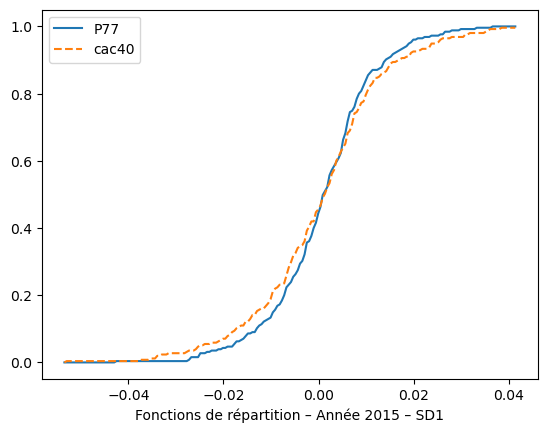

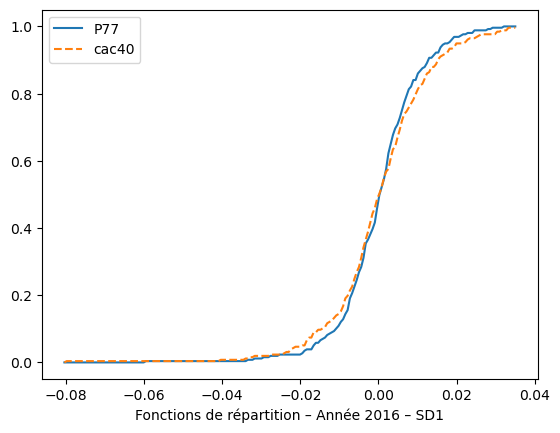

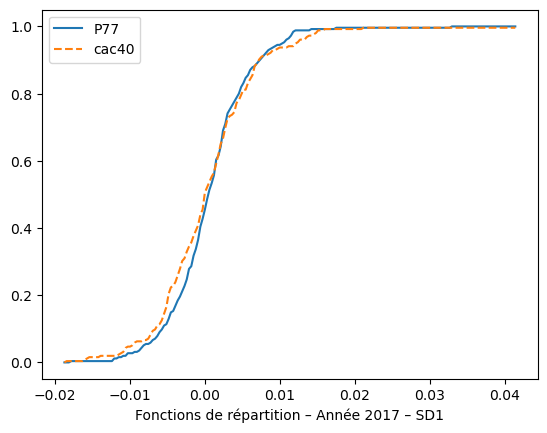

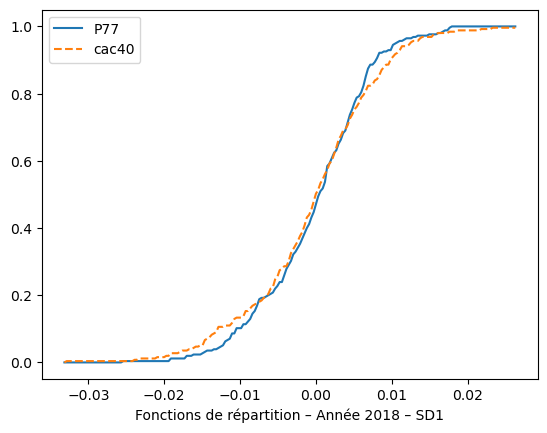

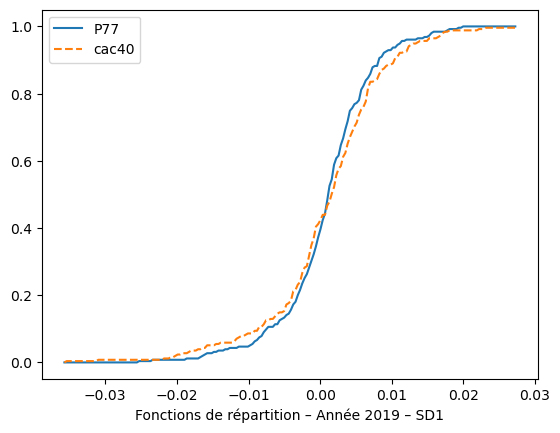

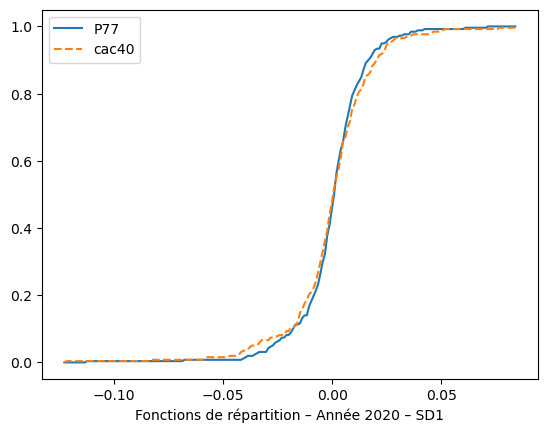

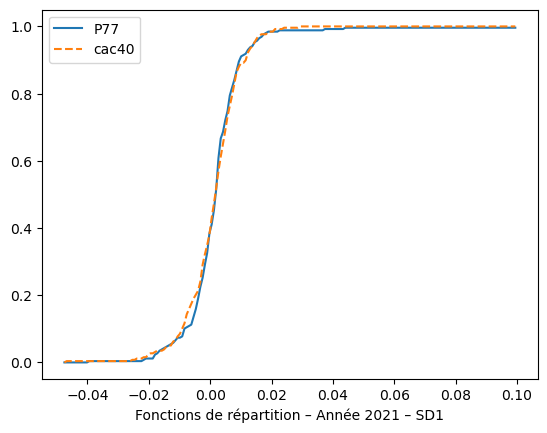

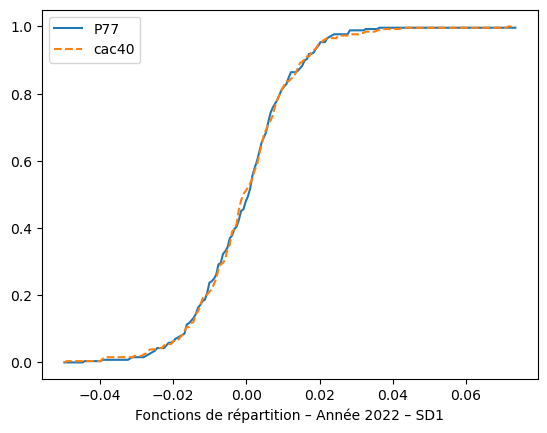

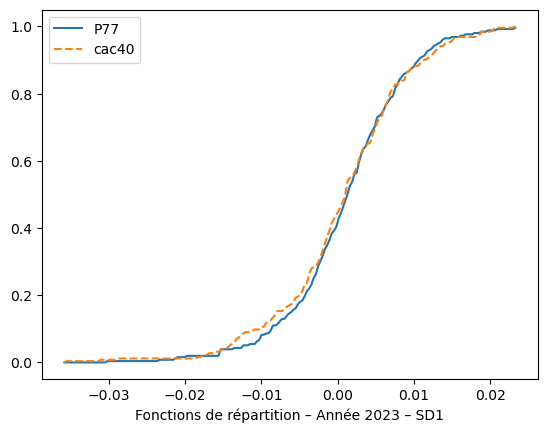

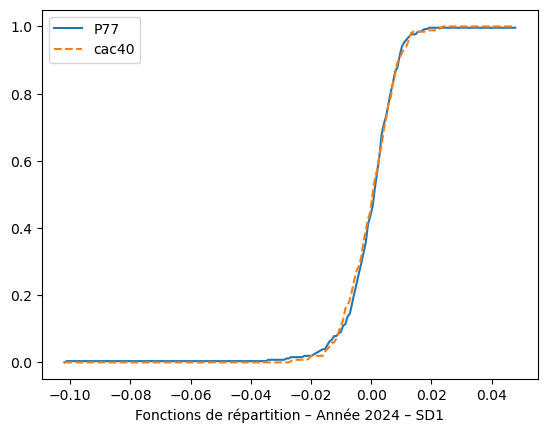

In [11]:
# On cherche le nombre de dominace stochastique pour chaque portefeuille
freq_SD1 = (SD1_matrix == 1).sum(axis=1)
#on prend le portefeuille qui domine le plus stochastiquement
best_portfolio = freq_SD1.idxmax()
année = range(2015, 2025)
ngrid = 200

b = 50
for y in année:
    echantillon_port = rendements_portefeuilles[best_portfolio].loc[f"{y}-01-01":f"{y}-12-31"].to_numpy()
    echantillon_cac  = rendements_portefeuilles["CAC40"].loc[f"{y}-01-01":f"{y}-12-31"].to_numpy()


    test_CDF = pysdtest.test_sd(
    echantillon_port,
    echantillon_cac,
    ngrid=ngrid,
    s=1,
    resampling="subsampling",
    b1=b,
    b2=b,
    quiet=True
    )
#on trace les fonctions de répartitions
    test_CDF.plot_CDF(save=True, title=f"Fonctions de répartition – Année {y} – SD1", label1=best_portfolio, label2='cac40', xlabel=f"Fonctions de répartition – Année {y} – SD1")

In [17]:
print(SD1_matrix.loc['P77'])

2014    0
2015    1
2016    0
2017    1
2018    1
2019    1
2020    0
2021    1
2022    1
2023    0
2024    0
Name: P77, dtype: object


question8.2:représentation de la fonction de répartion pour chaque année pour l'action la plus stable pour l'ordre 2

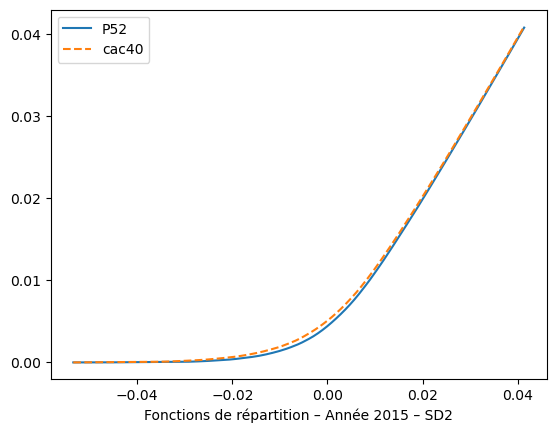

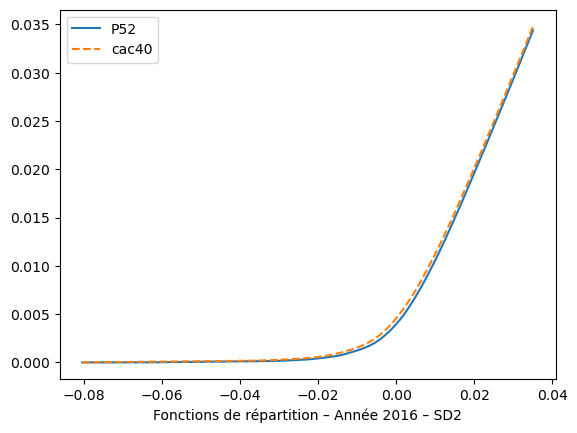

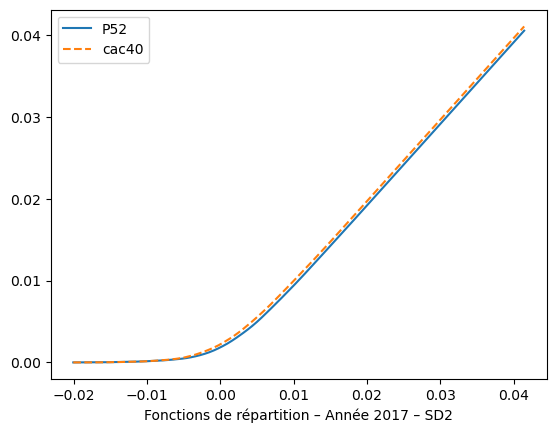

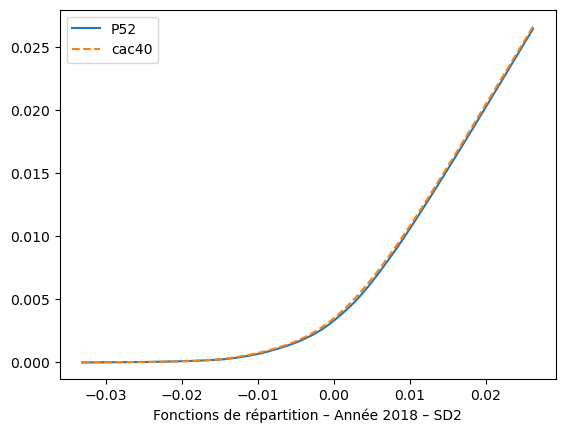

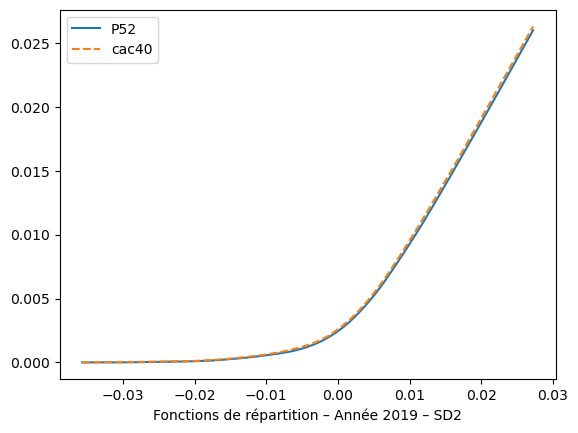

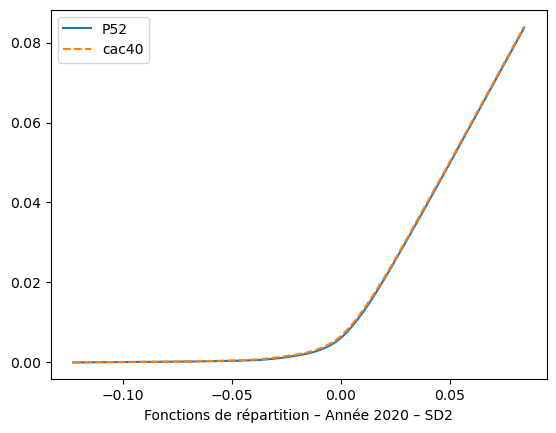

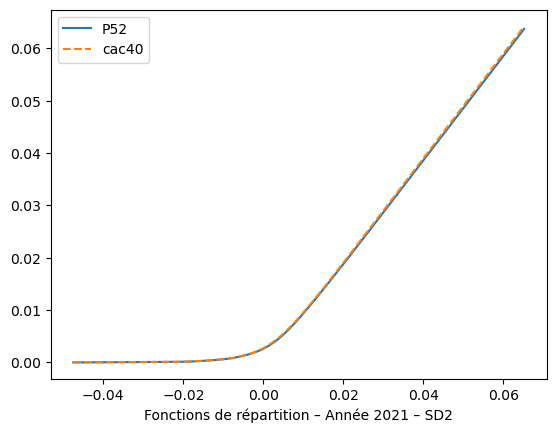

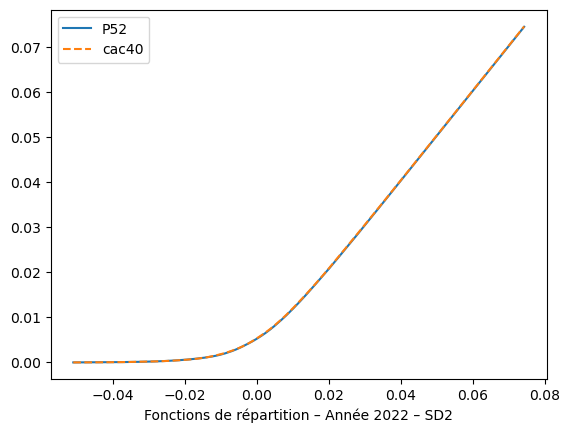

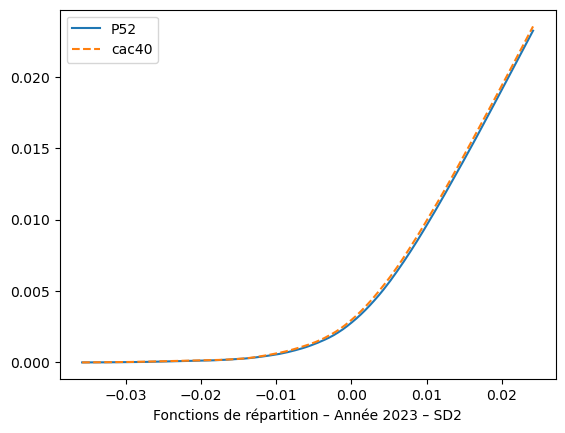

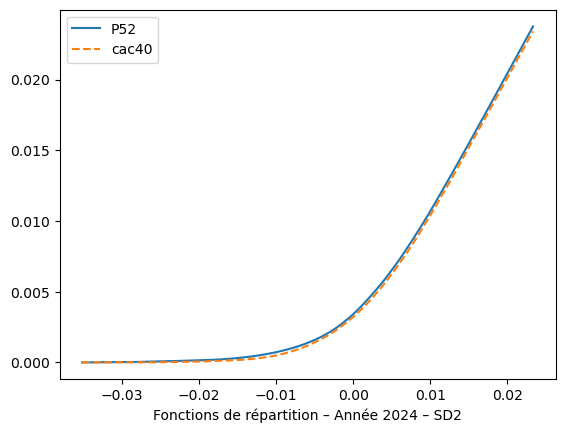

In [19]:
# On cherche le nombre de dominace stochastique pour chaque portefeuille
freq_SD2 = (SD2_matrix == 1).sum(axis=1)
#on prend le portefeuille qui domine le plus stochastiquement
best_portfolio = freq_SD2.idxmax()
année = range(2015, 2025)
ngrid = 200
b = 50
for y in année:
    echantillon_port = rendements_portefeuilles[best_portfolio].loc[f"{y}-01-01":f"{y}-12-31"].to_numpy()
    echantillon_cac  = rendements_portefeuilles["CAC40"].loc[f"{y}-01-01":f"{y}-12-31"].to_numpy()


    test_CDF = pysdtest.test_sd(
    echantillon_port,
    echantillon_cac,
    ngrid=ngrid,
    s=2,
    resampling="subsampling",
    b1=b,
    b2=b,
    quiet=True
    )
#on trace les fonctions de répartitions
    test_CDF.plot_CDF(save=True, title=f"Fonctions de répartition – Année {y} – SD1", label1=best_portfolio, label2='cac40', xlabel=f"Fonctions de répartition – Année {y} – SD2")

In [20]:
print(SD1_matrix.loc['P52'])

2014    1
2015    0
2016    0
2017    1
2018    0
2019    0
2020    0
2021    0
2022    2
2023    0
2024    0
Name: P52, dtype: object


question 9:Pour conclure sur cette partie, On peut déjà remarquer que certains résultats ne ressemblent pas à ce qui est attendu. Notamment le fait que la dominance stochastique à l'ordre 1 implique la dominace stochastique à l'ordre deux ce qui n'est pas toujours vérifié ici. J'imagine donc qu'il doit y avoir un probleme dans mon code ou bien un manque de précision de la méthode. De plus, on voit très bien qu'il n'y a pas de dominance stochastique à l'ordre 1 lorsque que l'on regarde les fonctions de répartition tracée. Alors que pour l'ordre 2 cela parait plus cohérent. Je pense donc que la comparaison des fonction de répartition est ici le meilleur moyen pour dire si il y a une dominance stochastique du moins pour l'ordre 1 et pour l'ordre 2 le test fonctionne bien d'autant plus qu'il est plus compliqué de décidé de la dominance en regardant les courbes.
L'intéret pour un investisseur ici va être de savoir s'il vaut mieux créer un portefeuille soit même
et quelles actions y mettre dedans ou bien investir directement dans le cac40. En effet il va pouvoir voir avec les différentes analyses si les portefeuilles créer domine souvent ou non le cac40 car avec cette analyse il a une vision sur 10 ans. Donc cela lui permettra de choisir la meilleur option parmis un choix de 100 portefeuilles si sa fonction d'utilité est croissante pour la dominance stochastique à l'ordre 1 et si sa fonction d'utilité est croissante et concave pour l'ordre 2 d'après les prpriétés vu en cours.


question 10:tableau permettant de comparer les portefeuilles qui dominait à l'année t avec le cac40 à l'année t+1

In [13]:
SD_matrix = SD1_matrix 

# Années considérées (on ne prend pas 2024 car t+1 n'existe pas)
année = range(2014, 2024)

# Liste pour stocker les résultats
resultats = []

for y in année:
    # Portefeuilles dominants à l'année y
    dominants = SD_matrix.index[SD_matrix[y] == 1].tolist()

    for p in dominants:
        # Rendements de l'année t+1
        rdmt_port = rendements_portefeuilles[p].loc[f"{y+1}-01-01":f"{y+1}-12-31"].dropna()
        rdmt_cac = rendements_portefeuilles["CAC40"].loc[f"{y+1}-01-01":f"{y+1}-12-31"].dropna()

        # Rendement moyen
        mean_port = rdmt_port.mean() * 252
        mean_cac  = rdmt_cac.mean()  * 252

        # Rendement médian
        median_port = rdmt_port.median() * 252
        median_cac  = rdmt_cac.median()  * 252

        # Écart-type
        std_port = rdmt_port.std() * np.sqrt(252)
        std_cac  = rdmt_cac.std()  * np.sqrt(252)

        # Min / Max
        min_port = rdmt_port.min() * 252
        max_port = rdmt_port.max() * 252
        min_cac  = rdmt_cac.min()  * 252
        max_cac  = rdmt_cac.max()  * 252

        # Skewness et Kurtosis
        skew_port = skew(rdmt_port)
        skew_cac  = skew(rdmt_cac)
        kurt_port = kurtosis(rdmt_port)
        kurt_cac  = kurtosis(rdmt_cac)

        # Sharpe ratio
        sharpe_port = (rdmt_port.mean()/rdmt_port.std()) * np.sqrt(252)
        sharpe_cac  = (rdmt_cac.mean()/rdmt_cac.std()) * np.sqrt(252)

        # VaR 
        var_port = np.percentile(rdmt_port, 5) * 252
        var_cac  = np.percentile(rdmt_cac, 5)  * 252

        # On stocke dans la liste les indicateurs de chaque portefeuille
        resultats.append({
            "Année": y,
            "Portefeuille": p,
            "Mean_Port": mean_port,
            "Mean_CAC": mean_cac,
            "Median_Port": median_port,
            "Median_CAC": median_cac,
            "Std_Port": std_port,
            "Std_CAC": std_cac,
            "Min_Port": min_port,
            "Min_CAC": min_cac,
            "Max_Port": max_port,
            "Max_CAC": max_cac,
            "Skew_Port": skew_port,
            "Skew_CAC": skew_cac,
            "Kurt_Port": kurt_port,
            "Kurt_CAC": kurt_cac,
            "Sharpe_Port": sharpe_port,
            "Sharpe_CAC": sharpe_cac,
            "VaR_Port": var_port,
            "VaR_CAC": var_cac
        })

# On transforme la liste en dataframe
df_performance = pd.DataFrame(resultats)
print(df_performance)

     Année Portefeuille  Mean_Port  Mean_CAC  Median_Port  Median_CAC  \
0     2014          P10   0.203694  0.114538     0.342447    0.245843   
1     2014          P13   0.174770  0.114538     0.265945    0.245843   
2     2014          P17   0.206099  0.114538     0.269465    0.245843   
3     2014          P30   0.185058  0.114538     0.241143    0.245843   
4     2014          P34   0.395113  0.114538     0.554030    0.245843   
..     ...          ...        ...       ...          ...         ...   
160   2023          P53  -0.024107 -0.022318     0.188332    0.090475   
161   2023          P57   0.006519 -0.022318    -0.036526    0.090475   
162   2023          P66   0.133851 -0.022318     0.266044    0.090475   
163   2023          P70  -0.002918 -0.022318     0.232596    0.090475   
164   2023          P79  -0.044023 -0.022318     0.134550    0.090475   

     Std_Port   Std_CAC   Min_Port    Min_CAC   Max_Port    Max_CAC  \
0    0.203460  0.224571 -12.069193 -13.469609  10.48

In [14]:
SD_matrix = SD2_matrix 

# Années considérées (on ne prend pas 2024 car t+1 n'existe pas)
année = range(2014, 2024)

# Liste pour stocker les résultats
resultats = []

for y in année:
    # Portefeuilles dominants à l'année y
    dominants = SD_matrix.index[SD_matrix[y] == 1].tolist()

    for p in dominants:
        # Rendements de l'année t+1
        rdmt_port = rendements_portefeuilles[p].loc[f"{y+1}-01-01":f"{y+1}-12-31"].dropna()
        rdmt_cac = rendements_portefeuilles["CAC40"].loc[f"{y+1}-01-01":f"{y+1}-12-31"].dropna()

        # Rendement moyen
        mean_port = rdmt_port.mean() * 252
        mean_cac  = rdmt_cac.mean()  * 252

        # Rendement médian
        median_port = rdmt_port.median() * 252
        median_cac  = rdmt_cac.median()  * 252

        # Écart-type
        std_port = rdmt_port.std() * np.sqrt(252)
        std_cac  = rdmt_cac.std()  * np.sqrt(252)

        # Min / Max
        min_port = rdmt_port.min() * 252
        max_port = rdmt_port.max() * 252
        min_cac  = rdmt_cac.min()  * 252
        max_cac  = rdmt_cac.max()  * 252

        # Skewness et Kurtosis
        skew_port = skew(rdmt_port)
        skew_cac  = skew(rdmt_cac)
        kurt_port = kurtosis(rdmt_port)
        kurt_cac  = kurtosis(rdmt_cac)

        # Sharpe ratio
        sharpe_port = (rdmt_port.mean()/rdmt_port.std()) * np.sqrt(252)
        sharpe_cac  = (rdmt_cac.mean()/rdmt_cac.std()) * np.sqrt(252)

        # VaR 
        var_port = np.percentile(rdmt_port, 5) * 252
        var_cac  = np.percentile(rdmt_cac, 5)  * 252

        # On stocke dans la liste les indicateurs de chaque portefeuille
        resultats.append({
            "Année": y,
            "Portefeuille": p,
            "Mean_Port": mean_port,
            "Mean_CAC": mean_cac,
            "Median_Port": median_port,
            "Median_CAC": median_cac,
            "Std_Port": std_port,
            "Std_CAC": std_cac,
            "Min_Port": min_port,
            "Min_CAC": min_cac,
            "Max_Port": max_port,
            "Max_CAC": max_cac,
            "Skew_Port": skew_port,
            "Skew_CAC": skew_cac,
            "Kurt_Port": kurt_port,
            "Kurt_CAC": kurt_cac,
            "Sharpe_Port": sharpe_port,
            "Sharpe_CAC": sharpe_cac,
            "VaR_Port": var_port,
            "VaR_CAC": var_cac
        })

# On transforme la liste en dataframe
df_performance2 = pd.DataFrame(resultats)
print(df_performance2)

     Année Portefeuille  Mean_Port  Mean_CAC  Median_Port  Median_CAC  \
0     2014          P10   0.203694  0.114538     0.342447    0.245843   
1     2014          P15   0.230253  0.114538     0.436108    0.245843   
2     2014          P17   0.206099  0.114538     0.269465    0.245843   
3     2014          P23   0.233788  0.114538     0.179791    0.245843   
4     2014          P24   0.180229  0.114538     0.360039    0.245843   
..     ...          ...        ...       ...          ...         ...   
258   2023          P85  -0.031620 -0.022318     0.097808    0.090475   
259   2023          P88  -0.021997 -0.022318     0.106169    0.090475   
260   2023          P94   0.010712 -0.022318     0.134201    0.090475   
261   2023          P95  -0.012793 -0.022318     0.220944    0.090475   
262   2023         P100   0.013198 -0.022318     0.047621    0.090475   

     Std_Port   Std_CAC   Min_Port    Min_CAC   Max_Port    Max_CAC  \
0    0.203460  0.224571 -12.069193 -13.469609  10.48

Question 11:

In [15]:
# On crée une liste vide pour stocker nos pourcentages de réussite
synthese_liste = []

# Nombre total de lignes 
total = len(df_performance)

# on regarde si le rendement moyen du portefeuille est supérieur à celui du cac40 puis on 
# fait un pourcentage de cela pour tous les portefeuilles qu'on a
nb_mieux_mean = (df_performance["Mean_Port"] > df_performance["Mean_CAC"]).sum()
pct_mean = (nb_mieux_mean / total) * 100
synthese_liste.append({"Indicateur": "Rendement Moyen", "% pour lequel l'indicateur du portefeuille est mieux que celui du cac40": pct_mean})

# on regarde si le rendement médian du portefeuille est supérieur à celui du cac40 puis on 
# fait un pourcentage de cela pour tous les portefeuilles qu'on a
nb_mieux_median = (df_performance["Median_Port"] > df_performance["Median_CAC"]).sum()
pct_median = (nb_mieux_median / total) * 100
synthese_liste.append({"Indicateur": "Rendement Médian", "% pour lequel l'indicateur du portefeuille est mieux que celui du cac40": pct_median})

# on regarde si la volatilité du portefeuille est inférieur à celle du cac40 puis on 
# fait un pourcentage de cela pour tous les portefeuilles qu'on a
nb_mieux_std = (df_performance["Std_Port"] < df_performance["Std_CAC"]).sum()
pct_std = (nb_mieux_std / total) * 100
synthese_liste.append({"Indicateur": "Volatilité ", "% pour lequel l'indicateur du portefeuille est mieux que celui du cac40": pct_std})

# on regarde si le rendement minimum du portefeuille est supérieur à celui du cac40 puis on 
# fait un pourcentage de cela pour tous les portefeuilles qu'on a
nb_mieux_min = (df_performance["Min_Port"] > df_performance["Min_CAC"]).sum()
pct_min = (nb_mieux_min / total) * 100
synthese_liste.append({"Indicateur": "Rendement Minimum", "% pour lequel l'indicateur du portefeuille est mieux que celui du cac40": pct_min})

# on regarde si le rendement maximum du portefeuille est supérieur à celui du cac40 puis on 
# fait un pourcentage de cela pour tous les portefeuilles qu'on a
nb_mieux_max = (df_performance["Max_Port"] > df_performance["Max_CAC"]).sum()
pct_max = (nb_mieux_max / total) * 100
synthese_liste.append({"Indicateur": "Rendement Maximum", "% pour lequel l'indicateur du portefeuille est mieux que celui du cac40": pct_max})

# on regarde si le skewness du portefeuille est supérieur à celui du cac40 puis on 
# fait un pourcentage de cela pour tous les portefeuilles qu'on a
nb_mieux_skew = (df_performance["Skew_Port"] > df_performance["Skew_CAC"]).sum()
pct_skew = (nb_mieux_skew / total) * 100
synthese_liste.append({"Indicateur": "Skewness", "% pour lequel l'indicateur du portefeuille est mieux que celui du cac40": pct_skew})

# on regarde si le kurtosis du portefeuille est inférieur à celui du cac40 puis on 
# fait un pourcentage de cela pour tous les portefeuilles qu'on a car le kurtosis mesure l'applatissement
# et donc montre si il y a de forte fluctuation ou non
nb_mieux_kurt = (df_performance["Kurt_Port"] < df_performance["Kurt_CAC"]).sum()
pct_kurt = (nb_mieux_kurt / total) * 100
synthese_liste.append({"Indicateur": "Kurtosis", "% pour lequel l'indicateur du portefeuille est mieux que celui du cac40": pct_kurt})

# on regarde si le ratio de sharpe du portefeuille est supérieur à celui du cac40 puis on 
# fait un pourcentage de cela pour tous les portefeuilles qu'on a
nb_mieux_sharpe = (df_performance["Sharpe_Port"] > df_performance["Sharpe_CAC"]).sum()
pct_sharpe = (nb_mieux_sharpe / total) * 100
synthese_liste.append({"Indicateur": "Ratio de Sharpe", "% pour lequel l'indicateur du portefeuille est mieux que celui du cac40": pct_sharpe})

# on regarde si la var du portefeuille est inférieur en valeur absolue à celle du cac40 puis on 
# fait un pourcentage de cela pour tous les portefeuilles qu'on a
nb_mieux_var = (df_performance["VaR_Port"].abs() < df_performance["VaR_CAC"].abs()).sum()
pct_var = (nb_mieux_var / total) * 100

synthese_liste.append({
    "Indicateur": "VaR", 
    "% pour lequel l'indicateur du portefeuille est mieux que celui du cac40": pct_var
})
#On transforme la liste en dataframe puis on l'affiche
df_synthese = pd.DataFrame(synthese_liste).set_index("Indicateur")
pd.options.display.float_format = '{:,.2f}%'.format

print(df_synthese)


                   % pour lequel l'indicateur du portefeuille est mieux que celui du cac40
Indicateur                                                                                
Rendement Moyen                                               85.45%                      
Rendement Médian                                              81.82%                      
Volatilité                                                    67.27%                      
Rendement Minimum                                             57.58%                      
Rendement Maximum                                             40.61%                      
Skewness                                                      49.09%                      
Kurtosis                                                      44.24%                      
Ratio de Sharpe                                               87.27%                      
VaR                                                           65.45%                      

D après les résutas au-dessus, investir dans un portefeuille à l'année t+1 alors qu'il a dominé à l'année t serait mieux que d'investir que dans le cac40 car à part le rendement maximum tous les indicateurs ont une réussite de plus de 50% ou très proche c est à dire que plus de la moitié des portefeuilles qui ont dominé à l'année t, à l'année t+1 leurs indicateurs sont meilleurs que celui du cac40. Donc on en déduit qu'on a plus de chance de gagner plus en investissant sur un portefeuille qui a dominé stochastiquement à l'année t. Cependant les résultats ne sont pas assez significatif pour qu'une dominance à l'année t implique un meilleur investissement à l'année t+1 du portefeuille.

In [16]:
# On crée une liste vide pour stocker nos pourcentages de réussite
synthese_liste = []

# Nombre total de lignes 
total = len(df_performance2)

# on regarde si le rendement moyen du portefeuille est supérieur à celui du cac40 puis on 
# fait un pourcentage de cela pour tous les portefeuilles qu'on a
nb_mieux_mean = (df_performance2["Mean_Port"] > df_performance2["Mean_CAC"]).sum()
pct_mean = (nb_mieux_mean / total) * 100
synthese_liste.append({"Indicateur": "Rendement Moyen", "% pour lequel l'indicateur du portefeuille est mieux que celui du cac40": pct_mean})

# on regarde si le rendement médian du portefeuille est supérieur à celui du cac40 puis on 
# fait un pourcentage de cela pour tous les portefeuilles qu'on a
nb_mieux_median = (df_performance["Median_Port"] > df_performance["Median_CAC"]).sum()
pct_median = (nb_mieux_median / total) * 100
synthese_liste.append({"Indicateur": "Rendement Médian", "% pour lequel l'indicateur du portefeuille est mieux que celui du cac40": pct_median})

# on regarde si la volatilité du portefeuille est inférieur à celle du cac40 puis on 
# fait un pourcentage de cela pour tous les portefeuilles qu'on a
nb_mieux_std = (df_performance2["Std_Port"] < df_performance2["Std_CAC"]).sum()
pct_std = (nb_mieux_std / total) * 100
synthese_liste.append({"Indicateur": "Volatilité ", "% pour lequel l'indicateur du portefeuille est mieux que celui du cac40": pct_std})

# on regarde si le rendement minimum du portefeuille est supérieur à celui du cac40 puis on 
# fait un pourcentage de cela pour tous les portefeuilles qu'on a
nb_mieux_min = (df_performance2["Min_Port"] > df_performance2["Min_CAC"]).sum()
pct_min = (nb_mieux_min / total) * 100
synthese_liste.append({"Indicateur": "Rendement Minimum", "% pour lequel l'indicateur du portefeuille est mieux que celui du cac40": pct_min})

# on regarde si le rendement maximum du portefeuille est supérieur à celui du cac40 puis on 
# fait un pourcentage de cela pour tous les portefeuilles qu'on a
nb_mieux_max = (df_performance2["Max_Port"] > df_performance2["Max_CAC"]).sum()
pct_max = (nb_mieux_max / total) * 100
synthese_liste.append({"Indicateur": "Rendement Maximum", "% pour lequel l'indicateur du portefeuille est mieux que celui du cac40": pct_max})

# on regarde si le skewness du portefeuille est supérieur à celui du cac40 puis on 
# fait un pourcentage de cela pour tous les portefeuilles qu'on a
nb_mieux_skew = (df_performance2["Skew_Port"] > df_performance2["Skew_CAC"]).sum()
pct_skew = (nb_mieux_skew / total) * 100
synthese_liste.append({"Indicateur": "Skewness", "% pour lequel l'indicateur du portefeuille est mieux que celui du cac40": pct_skew})

# on regarde si le kurtosis du portefeuille est inférieur à celui du cac40 puis on 
# fait un pourcentage de cela pour tous les portefeuilles qu'on a car le kurtosis mesure l'applatissement
# et donc montre si il y a de forte fluctuation ou non
nb_mieux_kurt = (df_performance2["Kurt_Port"] < df_performance2["Kurt_CAC"]).sum()
pct_kurt = (nb_mieux_kurt / total) * 100
synthese_liste.append({"Indicateur": "Kurtosis", "% pour lequel l'indicateur du portefeuille est mieux que celui du cac40": pct_kurt})

# on regarde si le ratio de sharpe du portefeuille est supérieur à celui du cac40 puis on 
# fait un pourcentage de cela pour tous les portefeuilles qu'on a
nb_mieux_sharpe = (df_performance2["Sharpe_Port"] > df_performance2["Sharpe_CAC"]).sum()
pct_sharpe = (nb_mieux_sharpe / total) * 100
synthese_liste.append({"Indicateur": "Ratio de Sharpe", "% pour lequel l'indicateur du portefeuille est mieux que celui du cac40": pct_sharpe})

# on regarde si la var du portefeuille est inférieur en valeur absolue à celle du cac40 puis on 
# fait un pourcentage de cela pour tous les portefeuilles qu'on a
nb_mieux_var = (df_performance2["VaR_Port"].abs() < df_performance2["VaR_CAC"].abs()).sum()
pct_var = (nb_mieux_var / total) * 100

synthese_liste.append({
    "Indicateur": "VaR", 
    "% pour lequel l'indicateur du portefeuille est mieux que celui du cac40": pct_var
})


df_synthese = pd.DataFrame(synthese_liste).set_index("Indicateur")
pd.options.display.float_format = '{:,.2f}%'.format

print(df_synthese)

                   % pour lequel l'indicateur du portefeuille est mieux que celui du cac40
Indicateur                                                                                
Rendement Moyen                                               92.02%                      
Rendement Médian                                              51.33%                      
Volatilité                                                    77.95%                      
Rendement Minimum                                             68.44%                      
Rendement Maximum                                             33.84%                      
Skewness                                                      48.67%                      
Kurtosis                                                      57.03%                      
Ratio de Sharpe                                               92.78%                      
VaR                                                           64.64%                      

In [ ]:
D après les résutas au-dessus, investir dans un portefeuille à l'année t+1 alors qu'il a dominé à l'année t serait mieux que d'investir que dans le cac40 car à part le rendement maximum tous les indicateurs ont une réussite de plus de 50% c est à dire que plus de la moitié des portefeuilles qui ont dominé à l'année t, à l'année t+1 leurs indicateurs sont meilleurs que celui du cac40.